# Agglomerative Hierarchical Clustering Benchmarking

In this notebook, we compare our custom-built Agglomerative Clustering algorithm (using a Bottom-Up approach with different linkage criteria) against the `scikit-learn` implementation. We will evaluate how it groups data into a specified number of clusters without using a central centroid.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from time import time
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering as SklearnAgglo

# Import our custom modules
from classical_ml.unsupervised.agglomerative import AgglomerativeClustering as CustomAgglo
from utils.metrics import purity_score

Data shape: (150, 2)


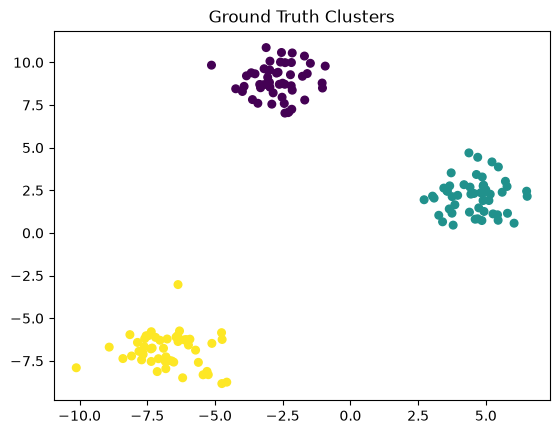

In [2]:
# 1. Generate Synthetic Data
# We use a smaller dataset (n=150) because pure Python hierarchical clustering is computationally expensive O(N^3)
X, y_true = make_blobs(n_samples=150, centers=3, cluster_std=1.0, random_state=42)

print(f"Data shape: {X.shape}")

# Visualize the ground truth
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', s=30)
plt.title("Ground Truth Clusters")
plt.show()

1. Custom Agglomerative Clustering (Average Linkage)
Purity Score : 1.0000
Time Taken   : 10.80532 seconds



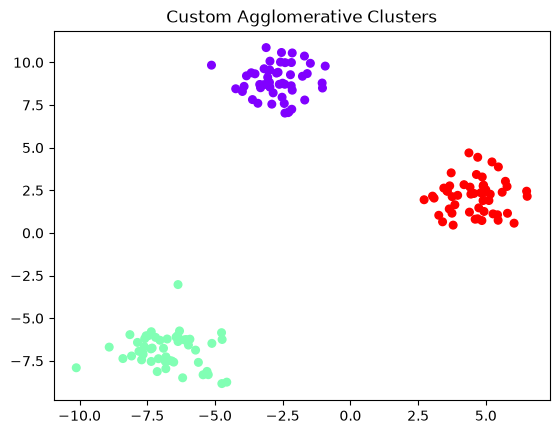

In [3]:
print("1. Custom Agglomerative Clustering (Average Linkage)")
start = time()

# Initialize with 3 clusters and 'average' linkage
custom_agglo = CustomAgglo(n_clusters=3, linkage='average')
preds_custom = custom_agglo.fit_predict(X)
time_custom = time() - start

print(f"Purity Score : {purity_score(y_true, preds_custom):.4f}")
print(f"Time Taken   : {time_custom:.5f} seconds\n")

# Plot custom predictions
plt.scatter(X[:, 0], X[:, 1], c=preds_custom, cmap='rainbow', s=30)
plt.title("Custom Agglomerative Clusters")
plt.show()

In [4]:
print("2. Scikit-Learn Agglomerative Clustering (Average Linkage)")
start = time()

# Match the parameters with our custom implementation
sk_agglo = SklearnAgglo(n_clusters=3, linkage='average')
preds_sk = sk_agglo.fit_predict(X)
time_sk = time() - start

print(f"Purity Score : {purity_score(y_true, preds_sk):.4f}")
print(f"Time Taken   : {time_sk:.5f} seconds\n")

2. Scikit-Learn Agglomerative Clustering (Average Linkage)
Purity Score : 1.0000
Time Taken   : 0.04548 seconds



## Conclusion
Both models successfully cluster the dataset into 3 groups using the **Bottom-Up (Agglomerative)** approach combined with **Average Linkage** (calculating the average distance between all points in two merging clusters).

This notebook perfectly highlights a critical concept in Machine Learning Engineering: **Algorithmic Complexity**. Our pure Python implementation uses nested `for-loops` to recalculate all pairwise distances between every active cluster at each step, resulting in an $O(N^3)$ time complexity. `scikit-learn`, on the other hand, utilizes highly optimized Cython code and advanced data structures (like Priority Queues and KD-Trees) to drastically reduce the number of distance calculations, making it run in a fraction of a millisecond.